# GRAFT: a self-contained AAM walkthrough

**Molecules → AAM → unique event candidates → allowed shuffles → growth animation.**

Install once from the repository root: `python -m pip install -e ".[notebook]"`. Select that Python environment and **Run All**. This example uses one worker and the Python growth backend; it does not need the optional fast engine, xTB, benchmark archives, or downloaded molecules. All input arrays and display helpers are below. You can copy this notebook anywhere after installation.

**GitHub:** the saved tables and 2D molecule drawings are visible in the preview. To play the 3D views, download/open the notebook in Jupyter and trust it. The viewers use the JavaScript bundled with the installed library, with no CDN request.

Example: **methanol → formaldehyde + H₂**, six explicit atoms on each side. Bond orders are illustrative formal values, not computed WBOs; coordinates are illustrative. This is an interface demonstration, not a mechanistic claim. Indices are zero-based.

The main computation is just `search_aam(problem, ...)` and then `decode_events(aam, ...)`. Everything else below is inspection or visualization.

In [1]:
import numpy as np
from collections import Counter
from dataclasses import asdict, replace
from pprint import pprint
from IPython.display import display, HTML, Image

from graft import MolecularEndpoint, AAMProblem, AAMSearchConfig, search_aam
from graft.postprocessing import EventDecodeConfig, decode_events

## 1. The entire molecule input

Change these arrays to try another reaction. Each WBO matrix uses the same order as its own element/coordinate arrays. Atom indices across endpoints are **not** prescribed matches: the search finds those. Here C is 0 and O is 1 on both sides only for readability.

In [2]:
elements = ("C", "O", "H", "H", "H", "H")
xyz_R = np.array([
    [ 0.00,  0.000,  0.000], [1.43, 0.00, 0.00],
    [-0.36,  1.030,  0.000], [-0.36, -0.515, 0.892],
    [-0.36, -0.515, -0.892], [1.77, 0.90, 0.00],
])
xyz_P = np.array([
    [ 0.00,  0.00, 0.00], [1.21, 0.00, 0.00],
    [-0.59,  0.94, 0.00], [-0.59, -0.94, 0.00],
    [ 3.30,  0.00, 0.00], [4.04, 0.00, 0.00],
])
wbo_R = np.array([
    [0, 1, 1, 1, 1, 0],  # C0: O1, H2, H3, H4
    [1, 0, 0, 0, 0, 1],  # O1: C0, H5
    [1, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
], dtype=float)
wbo_P = np.array([
    [0, 2, 1, 1, 0, 0],  # C0: double bond to O1, H2, H3
    [2, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1],  # H4–H5 is the separate H2 molecule
    [0, 0, 0, 0, 1, 0],
], dtype=float)
problem = AAMProblem(
    MolecularEndpoint(elements, xyz_R, wbo_R, label="Methanol"),
    MolecularEndpoint(elements, xyz_P, wbo_P, label="Formaldehyde + H2"),
    name="Six-atom methanol example",
)
print("Balanced:", problem.balanced, "| atoms per endpoint:", problem.source_atom_count)

Balanced: True | atoms per endpoint: 6


### Small display helpers, fully visible here

These helpers only draw the supplied data. They do not match atoms or decode events. RDKit is used for the static PNGs so GitHub can show the molecules; py3Dmol is used for the interactive view. In the witness view, matched atoms share a color. These are **atom correspondence colors**, not fragment partitions.

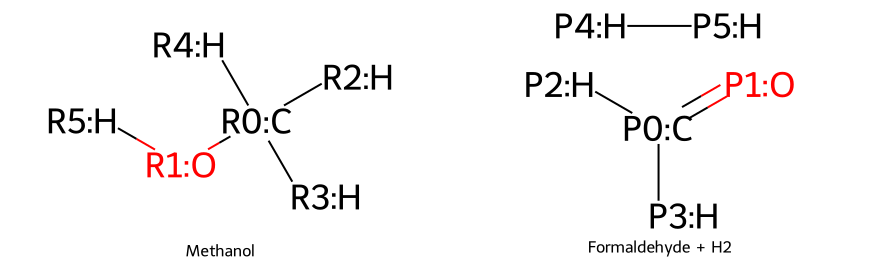

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw
import py3Dmol
from importlib.resources import files
from base64 import b64encode

palette = ["#4e79a7", "#e15759", "#59a14f", "#b07aa1", "#f28e2b", "#76b7b2"]
renderer_js = files("graft").joinpath("static/3Dmol-min.js").read_bytes()
renderer_url = "data:application/javascript;base64," + b64encode(renderer_js).decode()

def drawing_molecule(endpoint, prefix):
    mol = Chem.RWMol()
    for i, element in enumerate(endpoint.elements):
        atom = Chem.Atom(element)
        atom.SetNoImplicit(True)
        atom.SetProp("atomLabel", f"{prefix}{i}:{element}")
        mol.AddAtom(atom)
    kinds = {1: Chem.BondType.SINGLE, 2: Chem.BondType.DOUBLE, 3: Chem.BondType.TRIPLE}
    for a in range(endpoint.atom_count):
        for b in range(a + 1, endpoint.atom_count):
            if endpoint.wbo[a, b]:
                mol.AddBond(a, b, kinds[endpoint.wbo[a, b]])
    return mol.GetMol()

def draw_endpoints(mapping=None):
    mols = [drawing_molecule(problem.reactant, "R"), drawing_molecule(problem.product, "P")]
    colors = None
    if mapping is not None:
        rgb = [tuple(int(c[k:k+2], 16) / 255 for k in (1, 3, 5)) for c in palette]
        colors = [{r: rgb[r] for r in mapping}, {p: rgb[r] for r, p in mapping.items()}]
    png = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(440, 270),
        legends=[problem.reactant.label, problem.product.label], returnPNG=True,
        highlightAtomLists=[list(mapping), list(mapping.values())] if mapping is not None else [[], []],
        highlightAtomColors=colors if colors is not None else [{}, {}])
    display(png if isinstance(png, Image) else Image(data=png))

def show_mapping(mapping):
    view = py3Dmol.view(width=880, height=360, viewergrid=(1, 2), js=renderer_url)
    inverse = {p: r for r, p in mapping.items()}
    for side, endpoint in enumerate((problem.reactant, problem.product)):
        pane = (0, side)
        atoms = []
        for i, (element, xyz) in enumerate(zip(endpoint.elements, endpoint.coordinates)):
            neighbors = np.flatnonzero(endpoint.wbo[i]).tolist()
            atoms.append(dict(elem=element, serial=i, x=float(xyz[0]), y=float(xyz[1]), z=float(xyz[2]),
                              bonds=neighbors, bondOrder=[float(endpoint.wbo[i, j]) for j in neighbors]))
        view.addModel(viewer=pane)
        view.getModel(viewer=pane).addAtoms(atoms)
        for i, atom in enumerate(atoms):
            r = i if side == 0 else inverse[i]
            view.setStyle({"index": i}, {"stick": {"color": palette[r]},
                          "sphere": {"scale": 0.25, "color": palette[r]}}, viewer=pane)
            view.addLabel(f"{'R' if side == 0 else 'P'}{i}:{atom['elem']}",
                          {"position": {k: atom[k] for k in ("x", "y", "z")}, "fontSize": 11,
                           "fontColor": "black", "backgroundColor": "white", "backgroundOpacity": 0.75}, viewer=pane)
        view.rotate(25, "y", viewer=pane)
        view.rotate(15, "x", viewer=pane)
        view.zoomTo(viewer=pane)
        view.zoom(1.8, viewer=pane)
    return view

draw_endpoints()

## 2. Run AAM — independently of decoding

This cell exposes the main settings you are likely to edit. `seed_count` is the number of starting orders; `random_seed` makes their generation reproducible. The default branch limit is 100; it bounds a growth call, not the final count of all sweep histories. Competition is off and is not invoked here.

In [4]:
search_config = AAMSearchConfig(
    iso_tolerance=1.0,
    graph_floor=0.2,
    cut_floor=0.2,
    sweep_cuts=True,
    seed_count=1,
    random_seed=42,
    branch_limit=100,
    anchors=(),
)
aam = search_aam(problem, search_config, workers=1, execution="reference")
print(type(aam).__name__)
print("Capped:", aam.graph.capped)
pprint(asdict(aam.metrics))

AAMResult
Capped: False
{'checkpoint_restore_and_finalize_seconds': 2.00001522898674e-06,
 'checkpoint_seconds': 0.0,
 'completed_group_cache_hits': 5,
 'completed_group_calculations': 22,
 'completed_group_requests': 27,
 'cut_count': 6,
 'elapsed_seconds': 0.005765499779954553,
 'max_growth_candidates': 2,
 'max_live_branches': 2,
 'parent_merge_seconds': 3.3542048186063766e-05,
 'raw_result_count': 8,
 'retained_branch_count': 8,
 'subtree_branch_cap_count': 0,
 'symmetry_finalization_seconds': 0.0031487499363720417,
 'worker_returned_branch_count': 0,
 'worker_search_seconds': 0.0022382482420653105}


## 3. Inspect the raw search result

`aam.graph` retains search states and fragment decisions. A **context** is one cut/seed run; with one seed here, each context is one sweep animation. A **terminal** is a retained end state. A **path** is a recorded history through that graph. These are different counts from decoded event candidates.

In [5]:
graph = aam.graph
terminal_counts = Counter(graph.states[t].context for t in graph.terminals)
print(f"{len(graph.contexts)} contexts; {len(graph.states)} states; "
      f"{len(graph.transitions)} transitions; {len(graph.terminals)} terminals")
print("Stop reasons:", dict(Counter(stop.reason for stop in graph.stops)))
print("\nSweep   cut edges on R     terminals   source seed order")
for i, context in enumerate(graph.contexts):
    print(f"{i:>3}     {str(context.cuts or 'uncut'):<18} {terminal_counts[i]:>3}      {context.seed_order}")

6 contexts; 33 states; 27 transitions; 8 terminals
Stop reasons: {'objective_met': 8}

Sweep   cut edges on R     terminals   source seed order
  0     uncut                1      (3, 5, 4, 1, 2, 0)
  1     ((0, 1),)            2      (1, 5, 2, 0, 4, 3)
  2     ((0, 2),)            1      (3, 4, 5, 0, 1, 2)
  3     ((0, 3),)            2      (5, 1, 2, 0, 4, 3)
  4     ((0, 4),)            1      (3, 2, 5, 0, 1, 4)
  5     ((1, 5),)            1      (2, 3, 4, 1, 0, 5)


In [6]:
# Change the terminal ID to inspect another saved branch.
terminal = graph.terminals[0]
path = next(graph.paths(terminal))
print("Terminal:", terminal, "| context:", graph.states[terminal].context)
print("Representative R -> P:", path.mapping)
print("Transition IDs:", path.transitions)
print("\nCommitted fragments along this history:")
for fragment in path.hierarchy.fragments:
    pprint({"R atoms": fragment.r_atoms,
            "representative assignments": fragment.representative_assignments,
            "deferred edges": fragment.deferred_edges,
            "target generators": [g.images for g in fragment.target_generators]})

Terminal: 3 | context: 0
Representative R -> P: {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 4}
Transition IDs: (0, 1, 2)

Committed fragments along this history:
{'R atoms': (0, 1, 2, 3),
 'deferred edges': ((0, 4), (1, 5)),
 'representative assignments': ((0, 0), (1, 1), (2, 2), (3, 3)),
 'target generators': [(0, 1, 2, 3, 5, 4), (0, 1, 3, 2, 4, 5)]}
{'R atoms': (5,),
 'deferred edges': ((0, 4), (1, 5)),
 'representative assignments': ((5, 4),),
 'target generators': [(0, 1, 2, 3, 5, 4)]}
{'R atoms': (4,),
 'deferred edges': ((0, 4), (1, 5)),
 'representative assignments': ((4, 5),),
 'target generators': []}


## 4. Decode the saved AAM into unique event candidates

This is a separate call. `threshold` and `metal_threshold` define the final signed events; they do not change `iso_tolerance` or rerun AAM. `max_events=None` retains all event counts represented by the saved families, including nonminimum alternatives. There is no candidate-count cap.

Always inspect `decoded.complete`. It certifies the retained complete families in the requested window, **not exhaustive search over every possible mapping**. An interrupted family gives an incomplete result, not proof that an alternative is absent.

In [7]:
decode_config = EventDecodeConfig(
    threshold=0.5,
    metal_threshold=0.3,
    max_events=None,
    max_patterns_per_family=None,
    seconds_per_family=10.0,
)
decoded = decode_events(aam, decode_config)
candidates = decoded.candidates
print("Complete saved-family decoding:", decoded.complete)
print("Candidate    events    supporting families    source-index event edges")
for i, candidate in enumerate(candidates):
    print(i, "          ", candidate.total, "       ", candidate.family_ids, candidate.events)
print("Minimum candidates:", [c.total for c in decoded.minimum_candidates])
print("Incomplete family reports:", [r for r in decoded.family_reports if not r["complete"]])
assert decoded.complete
assert [c.total for c in candidates] == [4, 6]  # audit for the supplied example

Complete saved-family decoding: True
Candidate    events    supporting families    source-index event edges
0            4         [0, 1, 3, 4, 6] {'broken': ((0, 4), (1, 5)), 'formed': ((0, 1), (4, 5))}
1            6         [2, 5] {'broken': ((0, 3), (0, 4), (1, 5)), 'formed': ((0, 1), (0, 5), (3, 4))}
Minimum candidates: [4]
Incomplete family reports: []


Here “unique” means one signed-event class under the decoder's exact response symmetry. It does not mean a single atom bijection. A C–O → C=O increase is a positive event even though the bond already exists.

The catalogue groups unordered final fragment-pair sets while retaining constrained mapping families. A branch group can contain multiple families; several families can support the same event candidate.

In [8]:
catalogue = decoded.catalogue
print("Saved histories:", catalogue.path_count)
print("Unordered final branches:", catalogue.branch_count)
print("Constrained families:", len(catalogue.families))
print("Unique event candidates:", len(candidates))
print("Skipped partial paths:", catalogue.incomplete_paths)
first_branch_key, family_ids = next(iter(catalogue.branches.items()))
print("\nOne branch key (matching policy, unordered R/P fragment pairs):")
pprint(first_branch_key)
print("Its family IDs:", sorted(family_ids))

Saved histories: 8
Unordered final branches: 7
Constrained families: 7
Unique event candidates: 2
Skipped partial paths: 0

One branch key (matching policy, unordered R/P fragment pairs):
((0.2, 1.0), (((0, 1, 2, 3), (0, 1, 2, 3)), ((4,), (5,)), ((5,), (4,))))
Its family IDs: [0]


## 5. Select and inspect one witness

Change `choice` and rerun this cell and the next one. Candidate event edges always use **R indices**; obtain their target atoms by applying `candidate.mapping`. No reference/ground-truth mapping is supplied in this example.

Class ID: rxn_core.signed_events/v1:ca1aa841a189439be2b03c01584be774d276a32a6d0cf16a80ab1bcd56b92285
R atom -> P atom
R0:C -> P0:C
R1:O -> P1:O
R2:H -> P2:H
R3:H -> P3:H
R4:H -> P5:H
R5:H -> P4:H
broken [('R0–R4', 'P0–P5'), ('R1–R5', 'P1–P4')]
formed [('R0–R1', 'P0–P1'), ('R4–R5', 'P5–P4')]


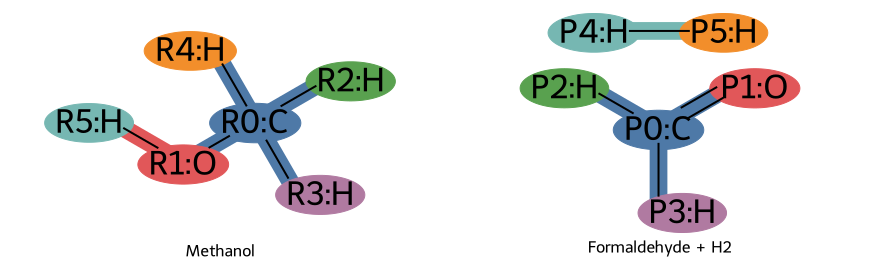

In [9]:
choice = 0
candidate = candidates[choice]
witness = candidate.mapping
print("Class ID:", candidate.id)
print("R atom -> P atom")
for r, p in sorted(witness.items()):
    print(f"R{r}:{problem.reactant.elements[r]} -> P{p}:{problem.product.elements[p]}")
for kind, pairs in candidate.events.items():
    print(kind, [(f"R{a}–R{b}", f"P{witness[a]}–P{witness[b]}") for a, b in pairs])
draw_endpoints(witness)

In [10]:
show_mapping(witness).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6. Inspect symmetry and ask which shuffles are allowed

`decoded.symmetry(candidate)` returns the supporting families' compressed actions, required edges, matching policy, and provenance. A `group` stores permutation generators; a `pool` stores a target pool. These actions are correlated and ordered. Orbit membership alone is **not** permission to swap atoms independently.

For a concrete answer, use `decoded.query(...)`. The result is `allowed`, `forbidden` within the retained families, or `unknown` if the query budget expires.

For the supplied example, swapping R2/R3 is allowed for `choice=0` but forbidden for `choice=1` within its saved families. Identical elements alone do not make a shuffle admissible. “Forbidden” describes the retained matching relation, not chemical impossibility.

In [11]:
evidence = decoded.symmetry(candidate)
print("Supporting families:", len(evidence))
pprint(evidence[0])

# Propose swapping methyl H atoms R2 and R3; membership in the saved
# families is checked, not assumed from their element or connectivity.
# Passing the whole mapping holds every other assignment fixed.
proposed = dict(witness)
proposed[2], proposed[3] = proposed[3], proposed[2]
shuffle = decoded.query(candidate, proposed, same_events=True)
print("\nExact two-atom swap:", shuffle.status)
print("Certified witness:", shuffle.mapping)
print("Supporting family:", shuffle.family_id)
if shuffle.status == "allowed":
    assert shuffle.mapping == proposed

Supporting families: 5
{'actions': (('pool', (4, 5)),
             ('group', ((0, 1, 2, 3, 5, 4),)),
             ('group', ((0, 1, 2, 3, 5, 4), (0, 1, 3, 2, 4, 5)))),
 'family_id': 0,
 'policy': (0.2, 1.0),
 'provenance': ({'archive': 'in_memory',
                 'terminal': 3,
                 'transitions': (0, 1, 2)},
                {'archive': 'in_memory',
                 'terminal': 28,
                 'transitions': (21, 22, 23)}),
 'required_edges': ((0, 1), (0, 2), (0, 3))}

Exact two-atom swap: allowed
Certified witness: {0: 0, 1: 1, 2: 3, 3: 2, 4: 5, 5: 4}
Supporting family: 0


In [12]:
# Passing only a partial condition lets unspecified atoms move together.
conditional = decoded.query(candidate, {2: proposed[2]}, same_events=True)
print("Partial condition R2 -> P" + str(proposed[2]) + ":", conditional.status)

other = candidates[1 if choice == 0 else 0]
same_class = decoded.query(candidate, other.mapping, same_events=True)
any_class = decoded.query(candidate, other.mapping, same_events=False)
print("Other event candidate, require same class:", same_class.status)
print("Other event candidate, allow any saved class:", any_class.status)
assert same_class.status == "forbidden"
assert any_class.status == "allowed"

# No AAM rerun: change only the event definition.
coarser = decode_events(aam, replace(decode_config, threshold=1.1, metal_threshold=None))
print("At event threshold 1.1:", [c.total for c in coarser.candidates])
assert coarser.complete and [c.total for c in coarser.candidates] == [0]

Partial condition R2 -> P3: allowed
Other event candidate, require same class: forbidden
Other event candidate, allow any saved class: allowed
At event threshold 1.1: [0]


## 7. A growth animation for each sweep

The viewer takes the **in-memory `aam`** directly. Each tab is a separate cut/seed context; use **Saved branch**, **Play**, and the event slider to inspect fragment growth, candidate tests, symmetry blocks, and the committed mapping. Cut edges are search constraints, not automatically broken bonds.

This diagnostic replay reruns recorded local fragment calls and verifies them against the saved search. It does not repeat the sweep search. It follows **one saved history per terminal**, shows compressed symmetry rather than all permutations, and does **not** replace the separate full event decoder above. Endpoint coordinates remain fixed; this is an algorithm animation, not molecular dynamics.

The supplied example is small, so we include every sweep. For a larger result, use `aam_growth_html(aam, context=2)` to inspect one sweep, or add `terminals=[...]` to select specific terminal paths. Capture is serial because it temporarily observes matcher calls.

In [13]:
from html import escape
from graft.viewers import aam_growth_html

growth_html = aam_growth_html(
    aam, context=None, title="Methanol example — one animation per sweep",
    event_threshold=decode_config.threshold,
    metal_event_threshold=decode_config.metal_threshold,
)
# An iframe isolates viewer JavaScript and CSS from other notebook outputs.
display({"text/html": '<iframe title="AAM sweep animations" style="width:100%;height:1020px;border:1px solid #ddd" '
             'srcdoc="' + escape(growth_html, quote=True) + '"></iframe>'}, raw=True)
print(f"Prepared {len(graph.contexts)} sweep tabs from the same in-memory AAM.")
# Optional standalone export, with all JavaScript/data embedded:
# from pathlib import Path
# Path("aam_growth.html").write_text(growth_html, encoding="utf-8")

<iframe title="AAM sweep animations" style="width:100%;height:1020px;border:1px solid #ddd" srcdoc="<!doctype html><html><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>Fragment-growth search trajectory</title><script>/*! For license information please see 3Dmol-min.js.LICENSE.txt */
var root,factory;root=this,factory=()=>(()=>{var __webpack_modules__={546(e,t,i){i.r(t),i.d(t,{CustomLinear:()=>CustomLinear,Gradient:()=>Gradient,GradientType:()=>GradientType,ROYGB:()=>ROYGB,RWB:()=>RWB,Sinebow:()=>Sinebow,builtinGradients:()=>a,getGradient:()=>s,normalizeValue:()=>n});var r=i(222);class GradientType{}function n(e,t,i){return t>=e?(i<e&&(i=e),i>t&&(i=t),{lo:e,hi:t,val:i}):(i>e&&(i=e),i<t&&(i=t),{lo:t,hi:e,val:i=e-i+t})}function s(e){if(e instanceof GradientType)return e;if(void 0!==e.gradient&&a[e.gradient]){let t=void 0===e.min?-1:e.min,i=void 0===e.max?1:e.max;return void 0===e.mid?void 0===e.colors?new a[e.gradient](t,i):new a[e.gradient](t,i,e.colors):new a[e.gradient](t,i,e.mid)}if("string"==typeof e.gradient&&e.gradient.startsWith("linear_")){let t=e.gradient.split("_");t.shift();let i=void 0===e.min?-1:e.min,r=void 0===e.max?1:e.max;return new CustomLinear(i,r,t)}return e}class RWB extends GradientType{constructor(e,t,i){super(),this.gradient="RWB",this.mult=1,this.mid=i,this.min=e,this.max=t,void 0===t&&Array.isArray(e)&&e.length>=2?(this.max=e[1],this.min=e[0]):e&&t&&!Array.isArray(e)&&(this.min=e,this.max=t)}range(){return void 0!==this.min&&void 0!==this.max?[this.min,this.max]:null}valueToHex(e,t){var i,r;if(e=this.mult*e,t?(i=t[0],r=t[1]):(i=this.min,r=this.max),void 0===e)return 16777215;var s=n(i,r,e);i=s.lo;var a,o=((r=s.hi)+i)/2;return(e=s.val)<(o=t&&void 0!==t[2]?t[2]:void 0!==this.mid?this.mid:(i+r)/2)?16711680+256*(a=Math.floor(255*Math.sqrt((e-i)/(o-i))))+a:e>o?65536*(a=Math.floor(255*Math.sqrt(1-(e-o)/(r-o))))+256*a+255:16777215}}class ROYGB extends GradientType{constructor(e,t){super(),this.gradient="ROYGB",this.mult=1,this.min=e,this.max=t,void 0===t&&Array.isArray(e)&&e.length>=2?(this.max=e[1],this.min=e[0]):e&&t&&!Array.isArray(e)&&(this.min=e,this.max=t)}valueToHex(e,t){var i,r;if(e=this.mult*e,t?(i=t[0],r=t[1]):(i=this.min,r=this.max),void 0===e)return 16777215;var s=n(i,r,e),a=((i=s.lo)+(r=s.hi))/2,o=(i+a)/2,l=(a+r)/2;return(e=s.val)<o?16711680+256*Math.floor(255*Math.sqrt((e-i)/(o-i)))+0:e<a?65536*Math.floor(255*Math.sqrt(1-(e-o)/(a-o)))+65280+0:e<l?65280+1*Math.floor(255*Math.sqrt((e-a)/(l-a))):0+256*Math.floor(255*Math.sqrt(1-(e-l)/(r-l)))+255}range(){return void 0!==this.min&&void 0!==this.max?[this.min,this.max]:null}}class Sinebow extends GradientType{constructor(e,t){super(),this.gradient="Sinebow",this.mult=1,this.min=e,this.max=t,void 0===t&&Array.isArray(e)&&e.length>=2&&(this.max=e[1],this.min=e[0]),t<e&&(this.mult=-1,this.min*=-1,this.max*=-1)}valueToHex(e,t){var i,r;if(e=this.mult*e,t?(i=t[0],r=t[1]):(i=this.min,r=this.max),void 0===e)return 16777215;var n=Gradient.normalizeValue(i,r,e);i=n.lo,r=n.hi;var s=((e=n.val)-i)/(r-i)*5/6+.5,a=Math.sin(Math.PI*s);a*=255*a;var o=Math.sin(Math.PI*(s+1/3));o*=255*o;var l=Math.sin(Math.PI*(s+2/3));return l*=255*l,65536*Math.floor(a)+256*Math.floor(l)+1*Math.floor(o)}range(){return void 0!==this.min&&void 0!==this.max?[this.min,this.max]:null}}class CustomLinear extends GradientType{constructor(e,t,i){var n;if(super(),this.gradient="linear",this.colors=new Array,Array.isArray(e)&&e.length>=2?(this.max=e[1],this.min=e[0],n=t):(this.min=e,this.max=t,n=i),n)for(let e of n)this.colors.push(r.CC.color(e));else this.colors.push(r.CC.color(0))}range(){return void 0!==this.min&&void 0!==this.max?[this.min,this.max]:null}valueToHex(e,t){var i,s;if(t?(i=t[0],s=t[1]):(i=this.min,s=this.max),void 0===e)return 16777215;var a=n(i,s,e);i=a.lo,s=a.hi,e=a.val;let o=this.colors.length,l=(s-i)/o,h=Math.min(Math.floor((e-i)/l),o-1),c=Math.min(h+1,o-1),d=(e-i-h*l)/l,u=this.colors[h],f=this.colors[c];return new r.Colo

Prepared 6 sweep tabs from the same in-memory AAM.


## 8. Optional controls: anchors, directions, conditional matching

These short cells use the same molecules. Anchors are in the original R→P index convention and are reversed automatically when needed. Both directions are searched sequentially with one worker.

Direction-local event IDs cannot simply be unioned into a common-frame bidirectional event quotient. Keep the two compressed results separate; convert concrete witnesses back with `to_input_mapping()`.

In [14]:
from graft import search_aam_directions

anchored_config = replace(search_config, anchors=((0, 0),))  # carbon R0 -> P0
runs = search_aam_directions(problem, anchored_config, direction="both", workers=1)
for run in runs:
    directed = decode_events(run.aam, decode_config)
    input_witness = run.to_input_mapping(directed.candidates[0].mapping)
    print(run.plan.direction, "| complete:", directed.complete,
          "| event counts:", [c.total for c in directed.candidates], "| R->P:", input_witness)
    assert input_witness[0] == 0
# Also supported: forward, reverse, smaller_first, larger_first.
# Size counts all explicit atoms; this example has equal-size endpoints.

R_to_P | complete: True | event counts: [4, 6] | R->P: {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 4}
P_to_R | complete: True | event counts: [4, 6] | R->P: {0: 0, 1: 1, 2: 2, 3: 3, 5: 4, 4: 5}


In [15]:
from graft import build_graph, match_fragment, FragmentMatchConfig, FragmentMatchContext
from graft import match_weighted_subgraph

source = build_graph(problem.reactant.elements, problem.reactant.wbo, bond_cut=0.2)
target = build_graph(problem.product.elements, problem.product.wbo, bond_cut=0.2)
fragment = match_fragment(
    source, target, seed=1,
    context=FragmentMatchContext(locked_mapping={0: 0}),
    config=FragmentMatchConfig(iso_tolerance=search_config.iso_tolerance, branch_limit=100),
)
print("Grow from O1 with carbon locked:", [dict(m) for m in fragment.matches])
print("Fragment call capped:", fragment.capped)

# A fixed-query match is different from growing a saturated fragment.
fixed_query = source.subgraph([0, 1]).copy()
fixed = match_weighted_subgraph(fixed_query, target, anchor_map={0: 0},
                               iso_tol=search_config.iso_tolerance, max_branches=100)
print("Fixed C–O query:", [m.mapping for m in fixed])
print("Fixed-query call capped:", fixed.capped)

Grow from O1 with carbon locked: [{0: 0, 1: 1, 2: 3, 3: 2}]
Fragment call capped: False
Fixed C–O query: [{0: 0, 1: 1}]
Fixed-query call capped: False


## 9. Inspect/serialize without hidden files

Both records below stay in memory. The raw archive preserves search structure; the candidate records are a compact report, not a replacement for families and symmetry constraints. Save the raw AAM too if you want to reconstruct the full decoder/query workflow later.

In [16]:
import json
from graft import aam_record, aam_from_record

raw_record = aam_record(aam)
restored = aam_from_record(json.loads(json.dumps(raw_record)))
# JSON turns tuples into lists; compare the JSON-normalized records.
assert json.loads(json.dumps(restored.graph.to_record())) == json.loads(json.dumps(aam.graph.to_record()))
restored_decoding = decode_events(restored, decode_config)
assert restored_decoding.complete
assert [(c.id, c.events) for c in restored_decoding.candidates] == [(c.id, c.events) for c in candidates]
candidate_records = [asdict(c) for c in candidates]
print("Raw record keys:", list(raw_record))
print("Candidate record keys:", list(candidate_records[0]))
print("Round-trip preserved the search graph:", True)
print("\nCandidate report:")
pprint(candidate_records)
print("\nAll example assertions passed.")

Raw record keys: ['schema', 'name', 'reactant', 'product', 'config', 'metrics', 'graph']
Candidate record keys: ['id', 'mapping', 'events', 'total', 'family_ids']
Round-trip preserved the search graph: True

Candidate report:
[{'events': {'broken': ((0, 4), (1, 5)), 'formed': ((0, 1), (4, 5))},
  'family_ids': [0, 1, 3, 4, 6],
  'id': 'rxn_core.signed_events/v1:ca1aa841a189439be2b03c01584be774d276a32a6d0cf16a80ab1bcd56b92285',
  'mapping': {0: 0, 1: 1, 2: 2, 3: 3, 4: 5, 5: 4},
  'total': 4},
 {'events': {'broken': ((0, 3), (0, 4), (1, 5)),
             'formed': ((0, 1), (0, 5), (3, 4))},
  'family_ids': [2, 5],
  'id': 'rxn_core.signed_events/v1:3534d3a07a7ccd09ca9f9ea3f8a75a3f049b5aaa3b9952ad41e97a88c87a955e',
  'mapping': {0: 0, 1: 1, 2: 3, 3: 5, 4: 4, 5: 2},
  'total': 6}]

All example assertions passed.


## What to adjust next

- **Search:** change `search_config`, rerun search, then decode. The published default uses the cut sweep and one seed; competition is experimental and off.
- **Event definition:** change `decode_config` and reuse `aam`.
- **Inspect:** change `terminal`, `choice`, the proposed shuffle, or the viewer's sweep tab.
- **Chirality — TODO:** the element/WBO AAM contract does not generally enforce CIP or E/Z stereochemistry. This example makes no chirality-preservation claim.

All scientific inputs and display helpers are in this notebook. The public library performs search, decoding, conditional queries, and verified replay. The [Python API guide](PYTHON_API.md) describes the full parameter set and completeness limits.